# 10 - Threshold And Hyperparameter Experiments

This notebook is for **decision-threshold** and **hyperparameter** experiments on:

- Logistic Regression
- Random Forest

Goal:
- keep the existing flight-disruption dataset and preprocessing pipeline
- run multiple training configurations
- sweep the disruption threshold
- log performance for each run
- compare **high-accuracy / low-recall** vs **higher-recall / lower-accuracy** operating points
- generate plots of all key metrics


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT


WindowsPath('C:/Code/flight-disruption-prediction')

In [2]:
import json
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

import xgboost as xgb

from src.utils import load_config
from src.model_training import ModelTrainer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

pd.set_option('display.float_format', lambda value: f'{value:.3f}')

METRIC_DECIMALS = 3


def metric_label(value, decimals: int = METRIC_DECIMALS) -> str:
    if pd.isna(value):
        return 'N/A'
    return f'{float(value):.{decimals}f}'


def annotate_bar_values(ax, decimals: int = METRIC_DECIMALS, fontsize: int = 8) -> None:
    for container in ax.containers:
        labels = []
        for patch in container.patches:
            value = patch.get_height()
            labels.append(metric_label(value, decimals))
        ax.bar_label(container, labels=labels, padding=3, fontsize=fontsize)


def annotate_line_endpoints(ax, decimals: int = METRIC_DECIMALS, fontsize: int = 8) -> None:
    # Endpoint labels give exact values without flooding threshold line charts.
    for line in ax.lines:
        x_data = np.asarray(line.get_xdata(), dtype=float)
        y_data = np.asarray(line.get_ydata(), dtype=float)
        finite = np.isfinite(x_data) & np.isfinite(y_data)
        if not finite.any():
            continue
        x_last = x_data[finite][-1]
        y_last = y_data[finite][-1]
        ax.annotate(
            metric_label(y_last, decimals),
            xy=(x_last, y_last),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=fontsize,
        )


OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'threshold_experiments'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
config

{'opensky': {'endpoint': 'https://opensky-network.org/api/states/all',
  'polling_interval_seconds': 30,
  'collection_hours': 1,
  'clientId': '${OPENSKY_CLIENT_ID}',
  'clientSecret': '${OPENSKY_CLIENT_SECRET}',
  'bbox': {'lamin': 45.0, 'lomin': -5.0, 'lamax': 55.0, 'lomax': 10.0}},
 'trajectory': {'max_gap_minutes': 15,
  'batch_size': 200000,
  'reconstruction_workers': 4,
  'reconstruction_partitions': 16},
 'features': {'mode': 'schedule_aware_direct',
  'schedule_sources': ['bts'],
  'batch_size': 200000,
  'partitions': 16,
  'pre_departure_hours': 2,
  'post_arrival_hours': 3,
  'fallback_duration_hours': 3,
  'downsample_interval_seconds': 60,
  'phase_detail_minutes': 15,
  'phase_interval_seconds': 30,
  'max_points_per_flight': 300,
  'min_points_per_flight': 10,
  'save_trajectory_sketches': True,
  'sketch_interval_seconds': 600,
  'sketch_phase_interval_seconds': 120,
  'sketch_phase_detail_minutes': 15,
  'sketch_max_points_per_flight': 80,
  'sketch_output_file': 'tr

In [3]:
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ml_dataset.parquet')
print(df.shape)
df.head(2)


(393339, 73)


,flight_key,region,source_dataset,scheduled_dep,scheduled_arr,origin,destination,cancelled,flight_duration,trajectory_length,mean_speed,max_speed,speed_std,mean_altitude,altitude_variance,vertical_rate_std,heading_variability,holding_pattern_count,altitude_change_count,unstable_descent_flag,trajectory_quality_score,is_full_flight,dep_anchor_confidence,arr_anchor_confidence,route_coverage_fraction,middle_gap_count,gap_fraction_of_flight,max_inter_ping_seconds,ping_interval_cv,dep_hour,dep_day_of_week,dep_month,is_weekend,is_peak_hour,origin_flight_count,dest_flight_count,origin_delay_rate,dest_delay_rate,origin_encoded,dest_encoded,route_gc_distance_km,origin_flights_1hr,dest_flights_1hr,lateral_deviation_mean_km,lateral_deviation_max_km,lateral_deviation_std_km,route_stretch_ratio,approach_deviation_km,altitude_deviation_mean_m,altitude_deviation_max_m,wind_speed,visibility,temperature,precipitation,weather_severity,weather_confidence,wind_speed_dest,visibility_dest,temperature_dest,precipitation_dest,weather_severity_dest,match_quality,label_source,match_score_minutes,match_anchor,match_confidence,training_eligible,feature_quality_score,delay_minutes,label,label_original,label_binary,disruption_subtype
0,DL442_20220102,US,bts,2022-01-02 16:00:00+00:00,2022-01-02 22:47:00+00:00,KJFK,KSFO,0,2370.000,426.930,232.274,269.224,47.412,8515.888,13472389.886,6.912,125.788,0,8,False,0.780,False,1.000,0.350,1.000,0,0.000,130.000,0.796,16,6,1,1,1,9635,8984,0.283,0.197,0.024,0.023,4152.061,0,6,None,None,None,None,None,None,None,11.000,3.000,53.000,0.000,1.000,High,4.000,10.000,52.000,0.000,0.000,multi_anchor_service_day<180m,bts_verified,174.667,arrival,0.089,True,1.000,-4.000,Normal,Normal,Normal,Normal
1,UA414_20220102,US,bts,2022-01-02 17:00:00+00:00,2022-01-02 23:14:00+00:00,KEWR,KSFO,0,1940.000,331.835,170.393,237.504,49.253,5924.062,15687870.704,3.461,186.298,0,0,False,0.720,False,0.350,1.000,1.000,0,0.000,10.000,0.000,17,6,1,1,1,8984,8984,0.333,0.196,0.023,0.023,4118.229,0,8,None,None,None,None,None,None,None,12.000,10.000,56.000,0.000,0.000,High,4.000,10.000,52.000,0.000,0.000,multi_anchor_service_day<180m,bts_verified,78.500,arrival,0.433,True,1.000,107.000,Late,Late,Disrupted,Late


In [4]:
trainer = ModelTrainer(config)
X_train, X_test, y_train, y_test = trainer.prepare_data(df)
class_names = list(trainer.label_encoder.classes_)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
normal_idx = class_to_idx['Normal']
disrupted_indices = [idx for idx, name in enumerate(class_names) if name != 'Normal']

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Classes:', class_names)
print('Train distribution:')
print(pd.Series(trainer.label_encoder.inverse_transform(y_train)).value_counts())
print('Test distribution:')
print(pd.Series(trainer.label_encoder.inverse_transform(y_test)).value_counts())


Train shape: (359737, 39)
Test shape: (33532, 39)
Classes: ['Disrupted', 'Normal']
Train distribution:
Normal       281959
Disrupted     77778
Name: count, dtype: int64
Test distribution:
Normal       25697
Disrupted     7835
Name: count, dtype: int64


## Helper Functions

Threshold logic used here:

- compute `disruption_probability = P(Late) + P(Cancelled)`
- if disruption probability is below the threshold, predict `Normal`
- if disruption probability is above the threshold, predict the most likely non-Normal class

This is useful for experimenting with an **operations-oriented** decision rule where we want to raise recall on disrupted flights.


In [5]:
def predict_with_disruption_threshold(probabilities: np.ndarray, threshold: float, normal_index: int, disrupted_index_list: list[int]) -> np.ndarray:
    probabilities = np.asarray(probabilities)
    disrupted_probability = probabilities[:, disrupted_index_list].sum(axis=1)
    preds = np.full(probabilities.shape[0], normal_index, dtype=int)

    triggered = disrupted_probability >= threshold
    if triggered.any():
        disrupted_scores = probabilities[triggered][:, disrupted_index_list]
        disrupted_choice_local = disrupted_scores.argmax(axis=1)
        preds[triggered] = np.array(disrupted_index_list)[disrupted_choice_local]
    return preds


def evaluate_threshold_run(y_true: pd.Series, y_pred: np.ndarray, probabilities: np.ndarray, threshold: float, model_name: str, params: dict, train_seconds: float) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    disrupted_true = (y_true != normal_idx).astype(int)
    disrupted_pred = (y_pred != normal_idx).astype(int)

    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    pr_auc_macro = np.nan
    if probabilities.shape[1] == y_true_bin.shape[1]:
        pr_auc_macro = average_precision_score(y_true_bin, probabilities, average='macro')

    metrics = {
        'model': model_name,
        'threshold': float(threshold),
        'train_seconds': float(train_seconds),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'disrupted_precision': float(precision_score(disrupted_true, disrupted_pred, zero_division=0)),
        'disrupted_recall': float(recall_score(disrupted_true, disrupted_pred, zero_division=0)),
        'disrupted_f1': float(f1_score(disrupted_true, disrupted_pred, zero_division=0)),
        'pr_auc_macro': None if pd.isna(pr_auc_macro) else float(pr_auc_macro),
        'mean_disruption_probability': float(probabilities[:, disrupted_indices].sum(axis=1).mean()),
        'predicted_disrupted_rate': float(disrupted_pred.mean()),
    }

    per_class_recall = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)
    per_class_precision = precision_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)

    for idx, class_name in enumerate(class_names):
        safe_name = class_name.lower().replace(' ', '_')
        metrics[f'recall_{safe_name}'] = float(per_class_recall[idx])
        metrics[f'precision_{safe_name}'] = float(per_class_precision[idx])
        metrics[f'f1_{safe_name}'] = float(per_class_f1[idx])

    for key, value in params.items():
        metrics[f'param_{key}'] = value

    return metrics


def run_experiment_grid(model_name: str, param_grid: dict, thresholds: list[float]) -> pd.DataFrame:
    rows = []
    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]

    for combo in product(*values):
        params = dict(zip(keys, combo))
        print(f'Training {model_name}: {params}')

        if model_name == 'logistic_regression':
            model = LogisticRegression(
                random_state=trainer.seed,
                max_iter=1500,
                n_jobs=None,
                **params,
            )
        elif model_name == 'random_forest':
            model = RandomForestClassifier(
                random_state=trainer.seed,
                n_jobs=-1,
                **params,
            )
        elif model_name == 'xgboost':
            model = xgb.XGBClassifier(
                objective='multi:softprob',
                num_class=len(class_names),
                random_state=trainer.seed,
                tree_method='hist',
                eval_metric='mlogloss',
                **params,
            )
        else:
            raise ValueError(f'Unsupported model: {model_name}')

        start = time.perf_counter()
        model.fit(X_train, y_train)
        train_seconds = time.perf_counter() - start
        probabilities = model.predict_proba(X_test)

        for threshold in thresholds:
            y_pred = predict_with_disruption_threshold(probabilities, threshold, normal_idx, disrupted_indices)
            rows.append(
                evaluate_threshold_run(
                    y_true=y_test,
                    y_pred=y_pred,
                    probabilities=probabilities,
                    threshold=threshold,
                    model_name=model_name,
                    params=params,
                    train_seconds=train_seconds,
                )
            )

    return pd.DataFrame(rows)

## Experiment Space

The grids are intentionally moderate so the notebook stays practical.

You can widen them later if you want deeper sweeps.


In [6]:
thresholds = [round(x, 2) for x in np.arange(0.20, 0.81, 0.05)]

logistic_grid = {
    'C': [0.25, 1.0, 4.0],
    'class_weight': [None, 'balanced'],
}

random_forest_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 12],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced', 'balanced_subsample'],
}

xgb_params_path = PROJECT_ROOT / 'models' / 'best_params_xgboost.json'
if xgb_params_path.exists():
    xgb_best_params = json.loads(xgb_params_path.read_text(encoding='utf-8'))
else:
    xgb_best_params = {
        'max_depth': 6,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 2,
    }

xgboost_grid = {
    'max_depth': sorted(set([int(xgb_best_params.get('max_depth', 6)), 4, 8])),
    'learning_rate': sorted(set([float(xgb_best_params.get('learning_rate', 0.05)), 0.03, 0.10])),
    'n_estimators': sorted(set([int(xgb_best_params.get('n_estimators', 300)), 200, 400])),
    'subsample': [float(xgb_best_params.get('subsample', 0.8))],
    'colsample_bytree': [float(xgb_best_params.get('colsample_bytree', 0.8))],
    'min_child_weight': [int(xgb_best_params.get('min_child_weight', 2))],
}

thresholds, logistic_grid, random_forest_grid, xgboost_grid

([np.float64(0.2),
  np.float64(0.25),
  np.float64(0.3),
  np.float64(0.35),
  np.float64(0.4),
  np.float64(0.45),
  np.float64(0.5),
  np.float64(0.55),
  np.float64(0.6),
  np.float64(0.65),
  np.float64(0.7),
  np.float64(0.75),
  np.float64(0.8)],
 {'C': [0.25, 1.0, 4.0], 'class_weight': [None, 'balanced']},
 {'n_estimators': [200, 400],
  'max_depth': [None, 12],
  'min_samples_leaf': [1, 5],
  'class_weight': ['balanced', 'balanced_subsample']},
 {'max_depth': [4, 7, 8],
  'learning_rate': [0.03, 0.1, 0.26093900056511754],
  'n_estimators': [200, 400, 405],
  'subsample': [0.7730164611600034],
  'colsample_bytree': [0.5105780203959702],
  'min_child_weight': [5]})

## Run Logistic Regression Experiments

In [7]:
lr_results = run_experiment_grid('logistic_regression', logistic_grid, thresholds)
lr_results.head()


Training logistic_regression: {'C': 0.25, 'class_weight': None}
Training logistic_regression: {'C': 0.25, 'class_weight': 'balanced'}
Training logistic_regression: {'C': 1.0, 'class_weight': None}
Training logistic_regression: {'C': 1.0, 'class_weight': 'balanced'}
Training logistic_regression: {'C': 4.0, 'class_weight': None}
Training logistic_regression: {'C': 4.0, 'class_weight': 'balanced'}


,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_disrupted,precision_disrupted,f1_disrupted,recall_normal,precision_normal,f1_normal,param_C,param_class_weight
0,logistic_regression,0.200,1.497,0.618,0.647,0.580,0.640,0.341,0.681,0.454,None,0.218,0.466,0.681,0.341,0.454,0.599,0.860,0.706,0.250,NaN
1,logistic_regression,0.250,1.497,0.706,0.718,0.625,0.640,0.400,0.517,0.451,None,0.218,0.302,0.517,0.400,0.451,0.764,0.838,0.799,0.250,NaN
2,logistic_regression,0.300,1.497,0.747,0.738,0.623,0.617,0.449,0.373,0.407,None,0.218,0.194,0.373,0.449,0.407,0.861,0.818,0.839,0.250,NaN
3,logistic_regression,0.350,1.497,0.766,0.737,0.598,0.589,0.500,0.256,0.339,None,0.218,0.120,0.256,0.500,0.339,0.922,0.803,0.858,0.250,NaN
4,logistic_regression,0.400,1.497,0.773,0.725,0.565,0.565,0.545,0.174,0.263,None,0.218,0.074,0.174,0.545,0.263,0.956,0.791,0.866,0.250,NaN


## Run Random Forest Experiments

In [8]:
rf_results = run_experiment_grid('random_forest', random_forest_grid, thresholds)
rf_results.head()


Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators':

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_disrupted,precision_disrupted,f1_disrupted,recall_normal,precision_normal,f1_normal,param_n_estimators,param_max_depth,param_min_samples_leaf,param_class_weight
0,random_forest,0.200,84.000,0.711,0.733,0.677,0.749,0.437,0.821,0.571,None,0.220,0.439,0.821,0.437,0.571,0.678,0.926,0.782,200,NaN,1,balanced
1,random_forest,0.250,84.000,0.775,0.787,0.722,0.757,0.514,0.723,0.601,None,0.220,0.329,0.723,0.514,0.601,0.791,0.904,0.844,200,NaN,1,balanced
2,random_forest,0.300,84.000,0.810,0.812,0.739,0.744,0.589,0.619,0.604,None,0.220,0.246,0.619,0.589,0.604,0.868,0.882,0.875,200,NaN,1,balanced
3,random_forest,0.350,84.000,0.826,0.818,0.737,0.720,0.663,0.520,0.583,None,0.220,0.183,0.520,0.663,0.583,0.919,0.863,0.890,200,NaN,1,balanced
4,random_forest,0.400,84.000,0.830,0.813,0.719,0.691,0.729,0.432,0.542,None,0.220,0.138,0.432,0.729,0.542,0.951,0.846,0.895,200,NaN,1,balanced


## Run XGBoost Experiments

In [9]:
xgb_results = run_experiment_grid('xgboost', xgboost_grid, thresholds)
xgb_results.head()


Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 0.7730164611600034, 'colsample_bytree': 0.5105780203959702, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 400, 'subsample': 0.7730164611600034, 'colsample_bytree': 0.5105780203959702, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 405, 'subsample': 0.7730164611600034, 'colsample_bytree': 0.5105780203959702, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.7730164611600034, 'colsample_bytree': 0.5105780203959702, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 400, 'subsample': 0.7730164611600034, 'colsample_bytree': 0.5105780203959702, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 405, 'subsample': 0.7730164611600034, 'colsample_bytre

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_disrupted,precision_disrupted,f1_disrupted,recall_normal,precision_normal,f1_normal,param_max_depth,param_learning_rate,param_n_estimators,param_subsample,param_colsample_bytree,param_min_child_weight
0,xgboost,0.200,11.999,0.672,0.697,0.637,0.709,0.397,0.779,0.526,None,0.222,0.458,0.779,0.397,0.526,0.639,0.904,0.749,4,0.030,200,0.773,0.511,5
1,xgboost,0.250,11.999,0.746,0.759,0.684,0.712,0.468,0.649,0.544,None,0.222,0.324,0.649,0.468,0.544,0.775,0.879,0.824,4,0.030,200,0.773,0.511,5
2,xgboost,0.300,11.999,0.786,0.784,0.696,0.693,0.544,0.518,0.530,None,0.222,0.223,0.518,0.544,0.530,0.867,0.855,0.861,4,0.030,200,0.773,0.511,5
3,xgboost,0.350,11.999,0.801,0.784,0.677,0.658,0.617,0.390,0.477,None,0.222,0.148,0.390,0.617,0.477,0.926,0.833,0.877,4,0.030,200,0.773,0.511,5
4,xgboost,0.400,11.999,0.806,0.774,0.648,0.627,0.701,0.293,0.413,None,0.222,0.098,0.293,0.701,0.413,0.962,0.817,0.883,4,0.030,200,0.773,0.511,5


## Combine And Save Results

In [10]:
results = pd.concat([lr_results, rf_results, xgb_results], ignore_index=True)
results = results.sort_values(['model', 'threshold', 'macro_f1'], ascending=[True, True, False]).reset_index(drop=True)

csv_path = OUTPUT_DIR / 'threshold_hyperparameter_experiments.csv'
parquet_path = OUTPUT_DIR / 'threshold_hyperparameter_experiments.parquet'
results.to_csv(csv_path, index=False)
results.to_parquet(parquet_path, index=False)

print('Saved CSV:', csv_path)
print('Saved Parquet:', parquet_path)
print('Rows logged:', len(results))
results.head()

Saved CSV: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\threshold_hyperparameter_experiments.csv
Saved Parquet: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\threshold_hyperparameter_experiments.parquet
Rows logged: 637


,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_disrupted,precision_disrupted,f1_disrupted,recall_normal,precision_normal,f1_normal,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight
0,logistic_regression,0.200,1.391,0.618,0.647,0.580,0.640,0.341,0.681,0.454,None,0.218,0.466,0.681,0.341,0.454,0.599,0.860,0.706,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression,0.200,1.477,0.618,0.647,0.580,0.640,0.341,0.681,0.454,None,0.218,0.466,0.681,0.341,0.454,0.599,0.860,0.706,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,logistic_regression,0.200,1.497,0.618,0.647,0.580,0.640,0.341,0.681,0.454,None,0.218,0.466,0.681,0.341,0.454,0.599,0.860,0.706,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logistic_regression,0.200,1.935,0.246,0.117,0.208,0.505,0.235,0.991,0.380,None,0.473,0.984,0.991,0.235,0.380,0.019,0.869,0.036,1.000,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,logistic_regression,0.200,1.842,0.246,0.117,0.208,0.505,0.235,0.991,0.380,None,0.473,0.984,0.991,0.235,0.380,0.019,0.869,0.036,4.000,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Best Configurations By Different Objectives

This helps compare two different product goals:

- **best accuracy**
- **best disrupted recall**


In [11]:
summary_views = {
    'best_accuracy': results.sort_values(['accuracy', 'macro_f1', 'disrupted_recall'], ascending=False).groupby('model').head(5),
    'best_disrupted_recall': results.sort_values(['disrupted_recall', 'macro_f1', 'accuracy'], ascending=False).groupby('model').head(5),
    'best_macro_f1': results.sort_values(['macro_f1', 'disrupted_recall', 'accuracy'], ascending=False).groupby('model').head(5),
}

for name, frame in summary_views.items():
    print(f'\n{name.upper()}')
    display_cols = [
        'model', 'threshold', 'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
        'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'train_seconds',
        'param_C', 'param_class_weight', 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf'
    ]
    display(frame[[c for c in display_cols if c in frame.columns]].reset_index(drop=True))



BEST_ACCURACY


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,xgboost,0.500,0.846,0.831,0.746,0.714,0.787,0.468,0.586,33.567,NaN,NaN,405.000,8.000,NaN
1,xgboost,0.500,0.846,0.831,0.745,0.714,0.786,0.466,0.586,33.821,NaN,NaN,400.000,8.000,NaN
2,xgboost,0.500,0.846,0.834,0.753,0.725,0.756,0.500,0.602,28.795,NaN,NaN,405.000,8.000,NaN
3,xgboost,0.500,0.846,0.833,0.753,0.725,0.757,0.499,0.602,29.352,NaN,NaN,400.000,8.000,NaN
4,xgboost,0.550,0.845,0.829,0.743,0.711,0.792,0.459,0.581,29.352,NaN,NaN,400.000,8.000,NaN
5,random_forest,0.400,0.831,0.814,0.720,0.691,0.741,0.428,0.543,172.545,NaN,balanced_subsample,400.000,NaN,1.000
6,random_forest,0.400,0.831,0.813,0.719,0.691,0.737,0.428,0.541,168.024,NaN,balanced,400.000,NaN,1.000
7,random_forest,0.400,0.830,0.813,0.719,0.691,0.729,0.432,0.542,84.000,NaN,balanced,200.000,NaN,1.000
8,random_forest,0.400,0.829,0.812,0.717,0.689,0.729,0.427,0.538,89.959,NaN,balanced_subsample,200.000,NaN,1.000
9,random_forest,0.550,0.828,0.810,0.713,0.685,0.733,0.416,0.531,159.289,NaN,balanced_subsample,400.000,NaN,5.000



BEST_DISRUPTED_RECALL


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.200,0.309,0.234,0.292,0.547,0.252,0.993,0.402,113.806,NaN,balanced_subsample,400.000,12.000,5.000
1,random_forest,0.200,0.312,0.239,0.296,0.549,0.253,0.993,0.403,98.745,NaN,balanced_subsample,400.000,12.000,1.000
2,random_forest,0.200,0.311,0.237,0.294,0.548,0.252,0.993,0.402,97.462,NaN,balanced,400.000,12.000,1.000
3,random_forest,0.200,0.310,0.236,0.294,0.548,0.252,0.993,0.402,94.088,NaN,balanced,400.000,12.000,5.000
4,random_forest,0.200,0.310,0.235,0.293,0.547,0.252,0.993,0.402,62.572,NaN,balanced_subsample,200.000,12.000,5.000
5,logistic_regression,0.200,0.246,0.117,0.208,0.505,0.235,0.991,0.380,1.935,1.000,balanced,NaN,NaN,NaN
6,logistic_regression,0.200,0.246,0.117,0.208,0.505,0.235,0.991,0.380,1.842,4.000,balanced,NaN,NaN,NaN
7,logistic_regression,0.200,0.246,0.117,0.208,0.505,0.235,0.991,0.380,1.877,0.250,balanced,NaN,NaN,NaN
8,logistic_regression,0.250,0.275,0.177,0.250,0.519,0.241,0.978,0.387,1.935,1.000,balanced,NaN,NaN,NaN
9,logistic_regression,0.250,0.275,0.177,0.250,0.519,0.241,0.978,0.387,1.842,4.000,balanced,NaN,NaN,NaN



BEST_MACRO_F1


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,xgboost,0.400,0.841,0.836,0.765,0.752,0.689,0.583,0.632,29.352,NaN,NaN,400.000,8.000,NaN
1,xgboost,0.400,0.841,0.836,0.765,0.751,0.689,0.582,0.631,28.795,NaN,NaN,405.000,8.000,NaN
2,xgboost,0.350,0.833,0.832,0.764,0.760,0.650,0.623,0.636,28.795,NaN,NaN,405.000,8.000,NaN
3,xgboost,0.350,0.833,0.832,0.764,0.760,0.649,0.624,0.636,29.352,NaN,NaN,400.000,8.000,NaN
4,xgboost,0.350,0.833,0.832,0.763,0.758,0.651,0.616,0.633,33.821,NaN,NaN,400.000,8.000,NaN
5,random_forest,0.300,0.813,0.814,0.742,0.745,0.596,0.618,0.607,168.024,NaN,balanced,400.000,NaN,1.000
6,random_forest,0.300,0.812,0.814,0.741,0.745,0.595,0.617,0.606,172.545,NaN,balanced_subsample,400.000,NaN,1.000
7,random_forest,0.450,0.816,0.815,0.740,0.737,0.611,0.588,0.599,160.852,NaN,balanced,400.000,NaN,5.000
8,random_forest,0.450,0.816,0.815,0.740,0.737,0.612,0.587,0.599,81.535,NaN,balanced,200.000,NaN,5.000
9,random_forest,0.450,0.816,0.815,0.739,0.737,0.609,0.588,0.599,83.284,NaN,balanced_subsample,200.000,NaN,5.000


## Prepare Plot Frames

In [12]:
metric_cols = [
    'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
    'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'pr_auc_macro',
]

best_by_macro_f1 = (
    results.sort_values(['model', 'macro_f1', 'disrupted_recall', 'accuracy'], ascending=[True, False, False, False])
    .groupby('model')
    .head(1)
)

plot_frames = []
for _, best_row in best_by_macro_f1.iterrows():
    model_name = best_row['model']
    model_subset = results[results['model'] == model_name].copy()

    param_cols = [col for col in model_subset.columns if col.startswith('param_')]
    for param_col in param_cols:
        if param_col in best_row.index and pd.notna(best_row[param_col]):
            model_subset = model_subset[model_subset[param_col] == best_row[param_col]]

    plot_frames.append(model_subset)

plot_df = pd.concat(plot_frames, ignore_index=True)
plot_df.head()

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_disrupted,precision_disrupted,f1_disrupted,recall_normal,precision_normal,f1_normal,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight
0,logistic_regression,0.200,1.497,0.618,0.647,0.580,0.640,0.341,0.681,0.454,None,0.218,0.466,0.681,0.341,0.454,0.599,0.860,0.706,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression,0.200,1.877,0.246,0.117,0.208,0.505,0.235,0.991,0.380,None,0.473,0.984,0.991,0.235,0.380,0.018,0.868,0.036,0.250,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,logistic_regression,0.250,1.497,0.706,0.718,0.625,0.640,0.400,0.517,0.451,None,0.218,0.302,0.517,0.400,0.451,0.764,0.838,0.799,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logistic_regression,0.250,1.877,0.275,0.177,0.250,0.519,0.241,0.978,0.387,None,0.473,0.949,0.978,0.241,0.387,0.060,0.901,0.113,0.250,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,logistic_regression,0.300,1.497,0.747,0.738,0.623,0.617,0.449,0.373,0.407,None,0.218,0.194,0.373,0.449,0.407,0.861,0.818,0.839,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot 1: All Key Metrics vs Threshold

For each model, this uses the **best macro-F1 hyperparameter setting**, then plots all major metrics across thresholds.


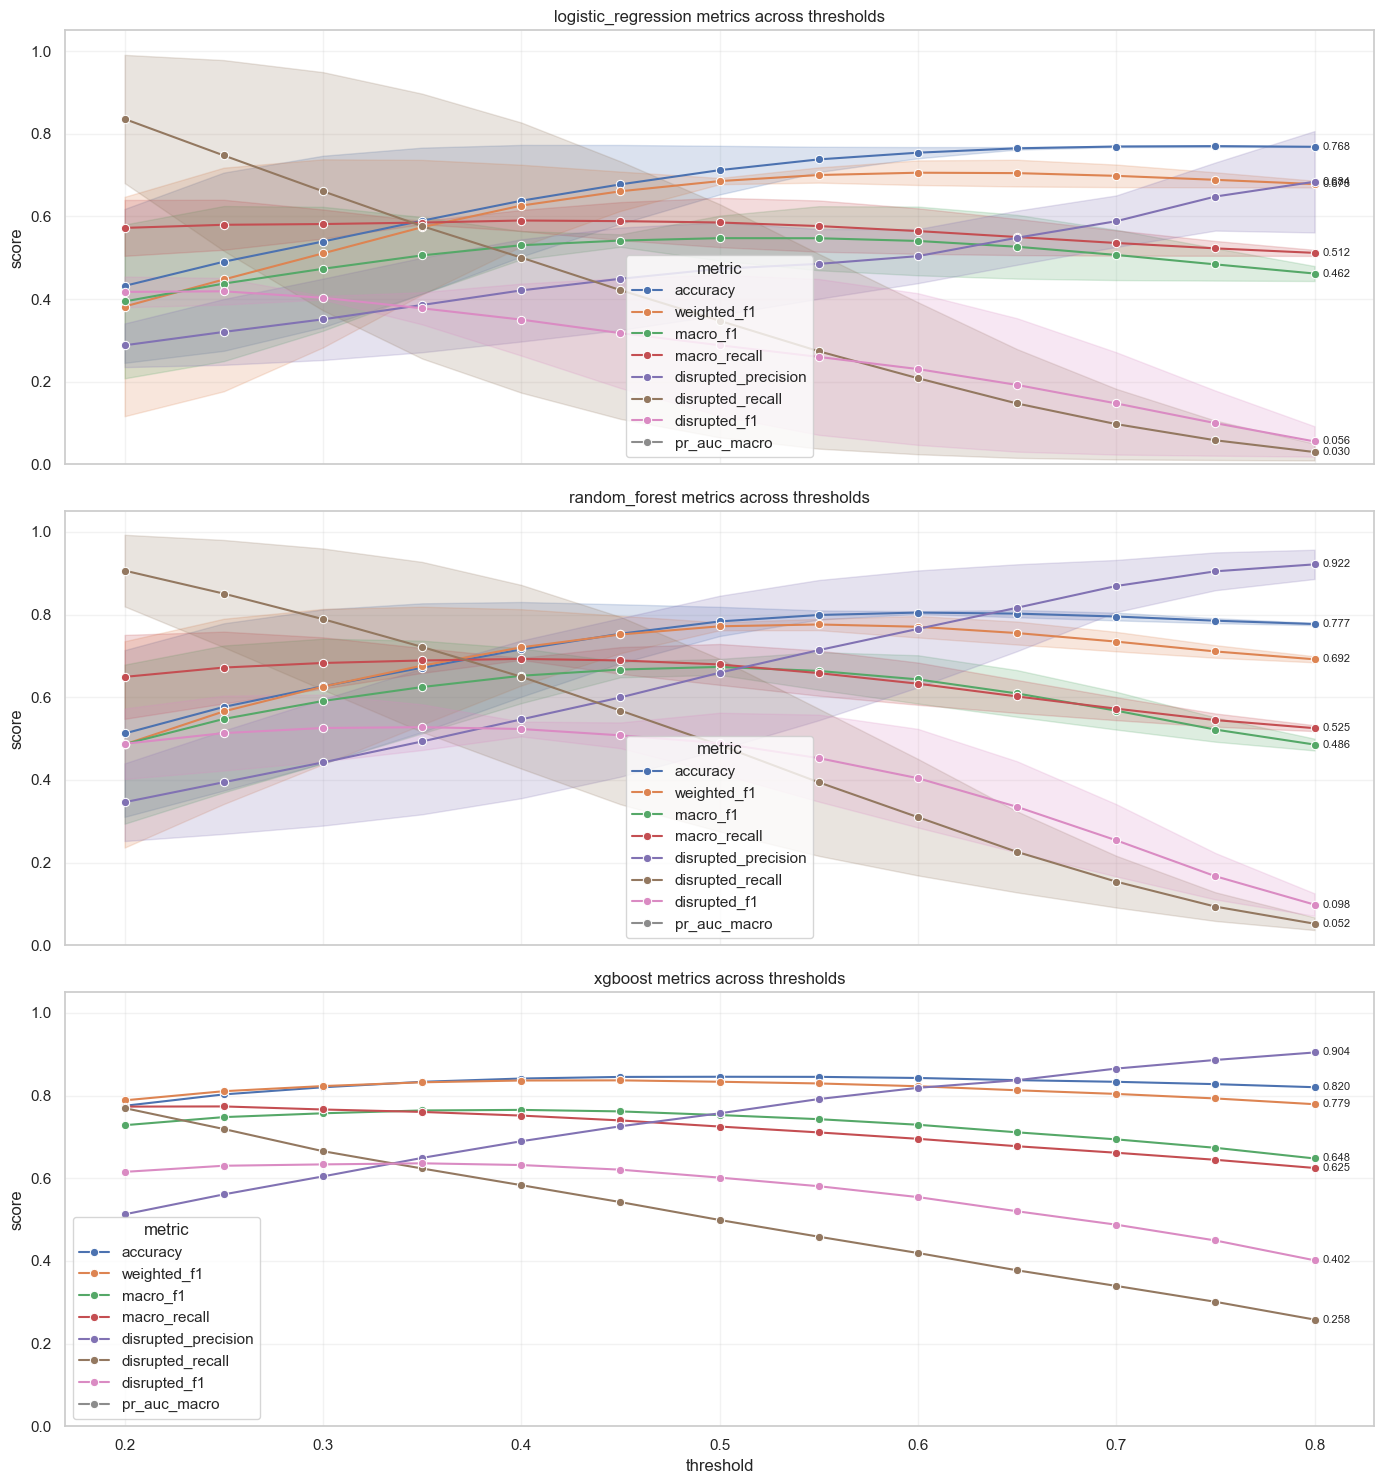

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\metrics_vs_threshold.png


In [13]:
long_df = plot_df.melt(
    id_vars=['model', 'threshold'],
    value_vars=metric_cols,
    var_name='metric',
    value_name='score',
)

models_to_plot = sorted(long_df['model'].unique())
fig, axes = plt.subplots(len(models_to_plot), 1, figsize=(14, 5 * len(models_to_plot)), sharex=True)
axes = np.atleast_1d(axes)

for ax, model_name in zip(axes, models_to_plot):
    subset = long_df[long_df['model'] == model_name]
    sns.lineplot(data=subset, x='threshold', y='score', hue='metric', marker='o', ax=ax)
    annotate_line_endpoints(ax)
    ax.set_title(f'{model_name} metrics across thresholds')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plot1_path = OUTPUT_DIR / 'metrics_vs_threshold.png'
plt.savefig(plot1_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot1_path)


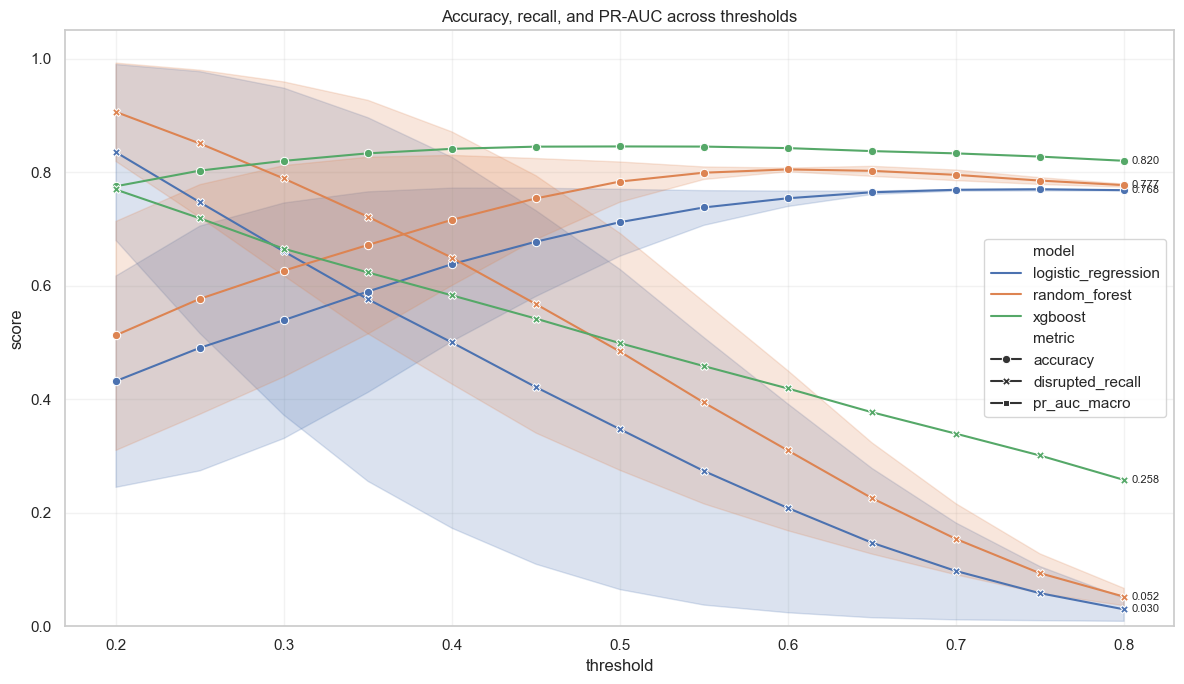

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\accuracy_recall_prauc_combined.png


In [14]:
metrics_for_plot = ['accuracy', 'disrupted_recall']
if 'pr_auc_macro' in plot_df.columns:
    metrics_for_plot.append('pr_auc_macro')

long_simple = plot_df[['model', 'threshold', *metrics_for_plot]].melt(
    id_vars=['model', 'threshold'],
    value_vars=metrics_for_plot,
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=long_simple,
    x='threshold',
    y='score',
    hue='model',
    style='metric',
    markers=True,
    dashes=False,
)
annotate_line_endpoints(ax)

plt.title('Accuracy, recall, and PR-AUC across thresholds')
plt.ylabel('score')
plt.xlabel('threshold')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.tight_layout()

single_plot_path = OUTPUT_DIR / 'accuracy_recall_prauc_combined.png'
plt.savefig(single_plot_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', single_plot_path)


## Plot 2: Accuracy vs Disrupted Recall

This shows the operating-point tradeoff directly.


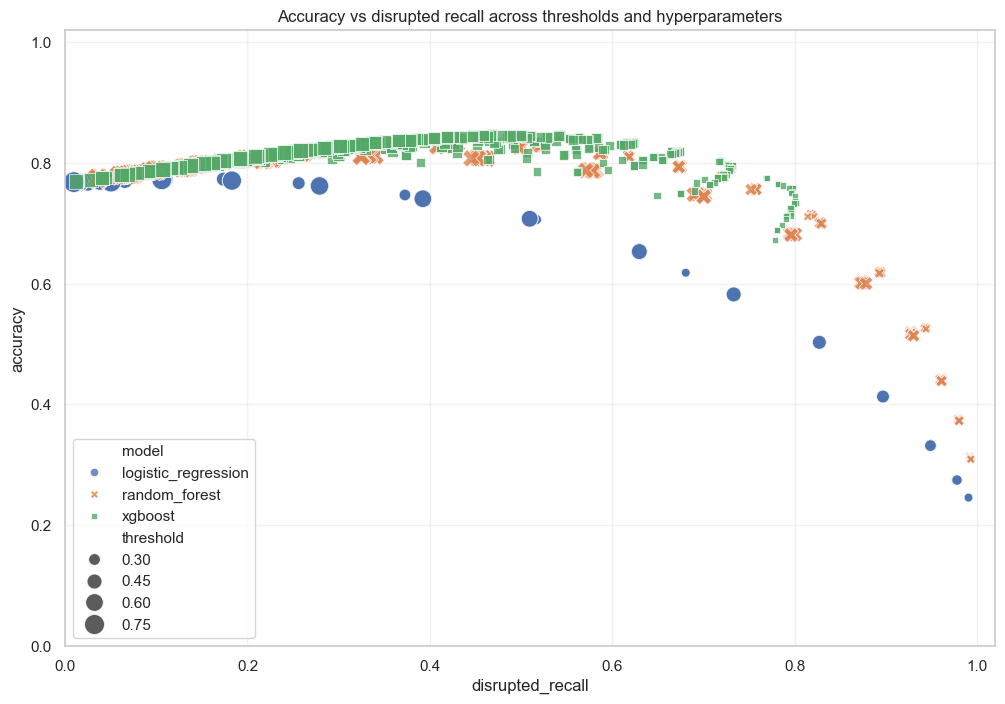

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\accuracy_vs_disrupted_recall.png


In [15]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=results,
    x='disrupted_recall',
    y='accuracy',
    hue='model',
    style='model',
    size='threshold',
    sizes=(40, 220),
    alpha=0.8,
)
plt.title('Accuracy vs disrupted recall across thresholds and hyperparameters')
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.25)
plot2_path = OUTPUT_DIR / 'accuracy_vs_disrupted_recall.png'
plt.savefig(plot2_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot2_path)


## Plot 3: Threshold Heatmaps For Best Hyperparameter Setting Per Model

Heatmaps make it easier to identify the threshold range that improves recall without collapsing accuracy.


In [1]:
for model_name in sorted(plot_df['model'].unique()):
    subset = plot_df[plot_df['model'] == model_name].copy()
    heat = subset.set_index('threshold')[metric_cols]
    plt.figure(figsize=(10, 6))
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis', cbar=True)
    plt.title(f'{model_name} threshold heatmap')
    plt.tight_layout()
    out_path = OUTPUT_DIR / f'{model_name}_threshold_heatmap.png'
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


NameError: name 'plot_df' is not defined

## Recommended Operating Points

This cell gives two useful views:

- **Balanced**: strongest macro-F1 with acceptable disrupted recall
- **Recall-first**: strongest disrupted recall without completely collapsing accuracy


In [ ]:
balanced_choice = (
    results[results['accuracy'] >= 0.60]
    .sort_values(['macro_f1', 'disrupted_recall', 'accuracy'], ascending=False)
    .groupby('model')
    .head(3)
)

recall_first_choice = (
    results[results['accuracy'] >= 0.50]
    .sort_values(['disrupted_recall', 'macro_f1', 'accuracy'], ascending=False)
    .groupby('model')
    .head(3)
)

print('BALANCED CHOICES')
display_cols = [
    'model', 'threshold', 'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
    'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'train_seconds',
    'param_C', 'param_class_weight', 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf'
]
display(balanced_choice[[c for c in display_cols if c in balanced_choice.columns]].reset_index(drop=True))

print('RECALL-FIRST CHOICES')
display(recall_first_choice[[c for c in display_cols if c in recall_first_choice.columns]].reset_index(drop=True))


BALANCED CHOICES


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.45,0.816742,0.814602,0.537064,0.516824,0.616125,0.580345,0.597700,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
1,random_forest,0.45,0.814595,0.812807,0.536695,0.516068,0.610047,0.581238,0.595294,81.175223,NaN,balanced_subsample,200.0,NaN,5.0
2,xgboost,0.35,0.828820,0.826719,0.535803,0.519006,0.643739,0.605616,0.624096,22.609545,NaN,NaN,200.0,8.0,NaN
3,xgboost,0.40,0.837379,0.829987,0.534463,0.509092,0.694940,0.546905,0.612099,22.609545,NaN,NaN,200.0,8.0,NaN
4,xgboost,0.30,0.814923,0.818332,0.532535,0.527521,0.593761,0.668028,0.628709,22.609545,NaN,NaN,200.0,8.0,NaN
5,random_forest,0.40,0.791453,0.798590,0.531470,0.528363,0.544680,0.677601,0.603913,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
6,logistic_regression,0.60,0.693904,0.709622,0.419624,0.503409,0.388900,0.502616,0.438506,3.237850,1.00,balanced,NaN,NaN,NaN
7,logistic_regression,0.60,0.693904,0.709622,0.419624,0.503409,0.388900,0.502616,0.438506,3.187870,4.00,balanced,NaN,NaN,NaN
8,logistic_regression,0.60,0.693875,0.709612,0.419618,0.503426,0.388883,0.502744,0.438544,3.365492,0.25,balanced,NaN,NaN,NaN


RECALL-FIRST CHOICES


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.20,0.500030,0.513528,0.363466,0.456860,0.313551,0.954180,0.471999,175.707398,NaN,balanced,400.0,NaN,5.0
1,random_forest,0.20,0.500149,0.513875,0.364236,0.456406,0.313309,0.951883,0.471443,80.013745,NaN,balanced,200.0,NaN,5.0
2,random_forest,0.25,0.597042,0.623019,0.420797,0.488577,0.358177,0.908998,0.513871,175.707398,NaN,balanced,400.0,NaN,5.0
3,logistic_regression,0.45,0.501223,0.532788,0.339659,0.489539,0.296628,0.807275,0.433843,3.187870,4.00,balanced,NaN,NaN,NaN
4,logistic_regression,0.45,0.501193,0.532755,0.339642,0.489526,0.296614,0.807275,0.433828,3.237850,1.00,balanced,NaN,NaN,NaN
5,logistic_regression,0.45,0.501044,0.532592,0.339553,0.489461,0.296545,0.807275,0.433754,3.365492,0.25,balanced,NaN,NaN,NaN
6,xgboost,0.20,0.756233,0.772410,0.493451,0.523932,0.487951,0.801149,0.606503,58.356116,NaN,NaN,400.0,10.0,NaN
7,xgboost,0.20,0.737922,0.756271,0.481919,0.515878,0.465786,0.801021,0.589047,66.168192,NaN,NaN,400.0,8.0,NaN
8,xgboost,0.20,0.750984,0.767766,0.490149,0.521351,0.481376,0.800000,0.601074,48.634061,NaN,NaN,323.0,10.0,NaN


## Notes

Interpretation guidance:

- If threshold is **lower**, the model predicts disruption more often.
  - disrupted recall usually goes **up**
  - accuracy may go **down**
  - false alarms may go **up**

- If threshold is **higher**, the model becomes more conservative.
  - accuracy often looks better
  - disrupted recall usually goes **down**
  - this is closer to a consumer-facing product that avoids too many false warnings

For airline/operations use, the most relevant metrics are usually:

- `disrupted_recall`
- `disrupted_precision`
- `macro_f1`
- `accuracy` as a secondary guardrail


## Snapshot Comparison

Compare the archived weighted runs side-by-side using the saved `models/model_comparison.json` artifacts.


In [ ]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

OUTPUT_DIR = REPO_ROOT / "outputs" / "threshold_experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNAPSHOT_RUNS = {
    'weighted_1_1_1': REPO_ROOT / 'weighted_1_1_1_run',
    'weighted_1_2_5': REPO_ROOT / 'weighted_1_2_5_run',
    'weighted_1_2_10': REPO_ROOT / 'weighted_1_2_10_run',
}

def load_snapshot_metrics(run_name: str, run_dir: Path) -> list[dict]:
    comparison_path = run_dir / 'models' / 'model_comparison.json'
    if not comparison_path.exists():
        print(f'Skipping {run_name}: missing {comparison_path}')
        return []

    payload = json.loads(comparison_path.read_text(encoding="utf-8"))
    rows = []
    weights_label = run_name.replace('weighted_', '').replace('_', '/')

    for item in payload.get("ranking", []):
        disrupted_metrics = item.get("per_class_metrics", {}).get("Disrupted", {})
        rows.append({
            'run_name': run_name,
            'weights': weights_label,
            'model': item.get('model'),
            'best_model_for_run': payload.get('best_model'),
            'accuracy': item.get('accuracy'),
            'weighted_f1': item.get('weighted_f1'),
            'macro_f1': item.get('macro_f1'),
            'cohens_kappa': item.get('cohens_kappa'),
            'pr_auc_macro': item.get('pr_auc_macro'),
            'disrupted_recall': disrupted_metrics.get('recall'),
            'disrupted_precision': disrupted_metrics.get('precision'),
        })
    return rows

snapshot_rows = []
for run_name, run_dir in SNAPSHOT_RUNS.items():
    snapshot_rows.extend(load_snapshot_metrics(run_name, run_dir))

snapshot_results = pd.DataFrame(snapshot_rows)
snapshot_results


,run_name,weights,model,best_model_for_run,accuracy,weighted_f1,macro_f1,cohens_kappa,pr_auc_macro,disrupted_recall,disrupted_precision
0,weighted_1_1_1,1/1/1,xgboost,xgboost,0.805678,0.812536,0.749002,0.500138,None,0.707211,0.567551
1,weighted_1_1_1,1/1/1,random_forest,xgboost,0.818860,0.781761,0.655250,0.341099,None,0.278111,0.839045
2,weighted_1_1_1,1/1/1,logistic_regression,xgboost,0.653018,0.677869,0.601770,0.230273,None,0.629738,0.360989
3,weighted_1_2_5,1/2/5,xgboost,xgboost,0.789813,0.799453,0.735867,0.476028,None,0.723038,0.537323
4,weighted_1_2_5,1/2/5,random_forest,xgboost,0.818860,0.781761,0.655250,0.341099,None,0.278111,0.839045
5,weighted_1_2_5,1/2/5,logistic_regression,xgboost,0.653018,0.677869,0.601770,0.230273,None,0.629738,0.360989
6,weighted_1_2_10,1/2/10,xgboost,xgboost,0.769295,0.782447,0.719467,0.447251,None,0.744352,0.504280
7,weighted_1_2_10,1/2/10,random_forest,xgboost,0.815937,0.776077,0.644666,0.323431,None,0.260370,0.844022
8,weighted_1_2_10,1/2/10,logistic_regression,xgboost,0.388793,0.375309,0.387883,0.077308,None,0.914486,0.265469


In [ ]:
from IPython.display import display
import pandas as pd

comparison_table = snapshot_results[['weights', 'model', 'accuracy', 'disrupted_recall', 'disrupted_precision', 'weighted_f1', 'macro_f1', 'cohens_kappa', 'pr_auc_macro']].copy()
comparison_table = comparison_table.sort_values(['model', 'weights']).reset_index(drop=True)

def fmt3(x):
    return 'N/A' if pd.isna(x) else f'{x:.3f}'

display(
    comparison_table.style.format({
        'accuracy': fmt3,
        'disrupted_recall': fmt3,
        'disrupted_precision': fmt3,
        'weighted_f1': fmt3,
        'macro_f1': fmt3,
        'cohens_kappa': fmt3,
        'pr_auc_macro': fmt3,
    })
)

comparison_csv_path = OUTPUT_DIR / 'weighted_run_comparison.csv'
comparison_table.to_csv(comparison_csv_path, index=False)
print('Saved:', comparison_csv_path)


,weights,model,accuracy,disrupted_recall,disrupted_precision,weighted_f1,macro_f1,cohens_kappa,pr_auc_macro
0,1/1/1,logistic_regression,0.6530,0.6297,0.3610,0.6779,0.6018,0.2303,N/A
1,1/2/10,logistic_regression,0.3888,0.9145,0.2655,0.3753,0.3879,0.0773,N/A
2,1/2/5,logistic_regression,0.6530,0.6297,0.3610,0.6779,0.6018,0.2303,N/A
3,1/1/1,random_forest,0.8189,0.2781,0.8390,0.7818,0.6552,0.3411,N/A
4,1/2/10,random_forest,0.8159,0.2604,0.8440,0.7761,0.6447,0.3234,N/A
5,1/2/5,random_forest,0.8189,0.2781,0.8390,0.7818,0.6552,0.3411,N/A
6,1/1/1,xgboost,0.8057,0.7072,0.5676,0.8125,0.7490,0.5001,N/A
7,1/2/10,xgboost,0.7693,0.7444,0.5043,0.7824,0.7195,0.4473,N/A
8,1/2/5,xgboost,0.7898,0.7230,0.5373,0.7995,0.7359,0.4760,N/A


Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\weighted_run_comparison.csv


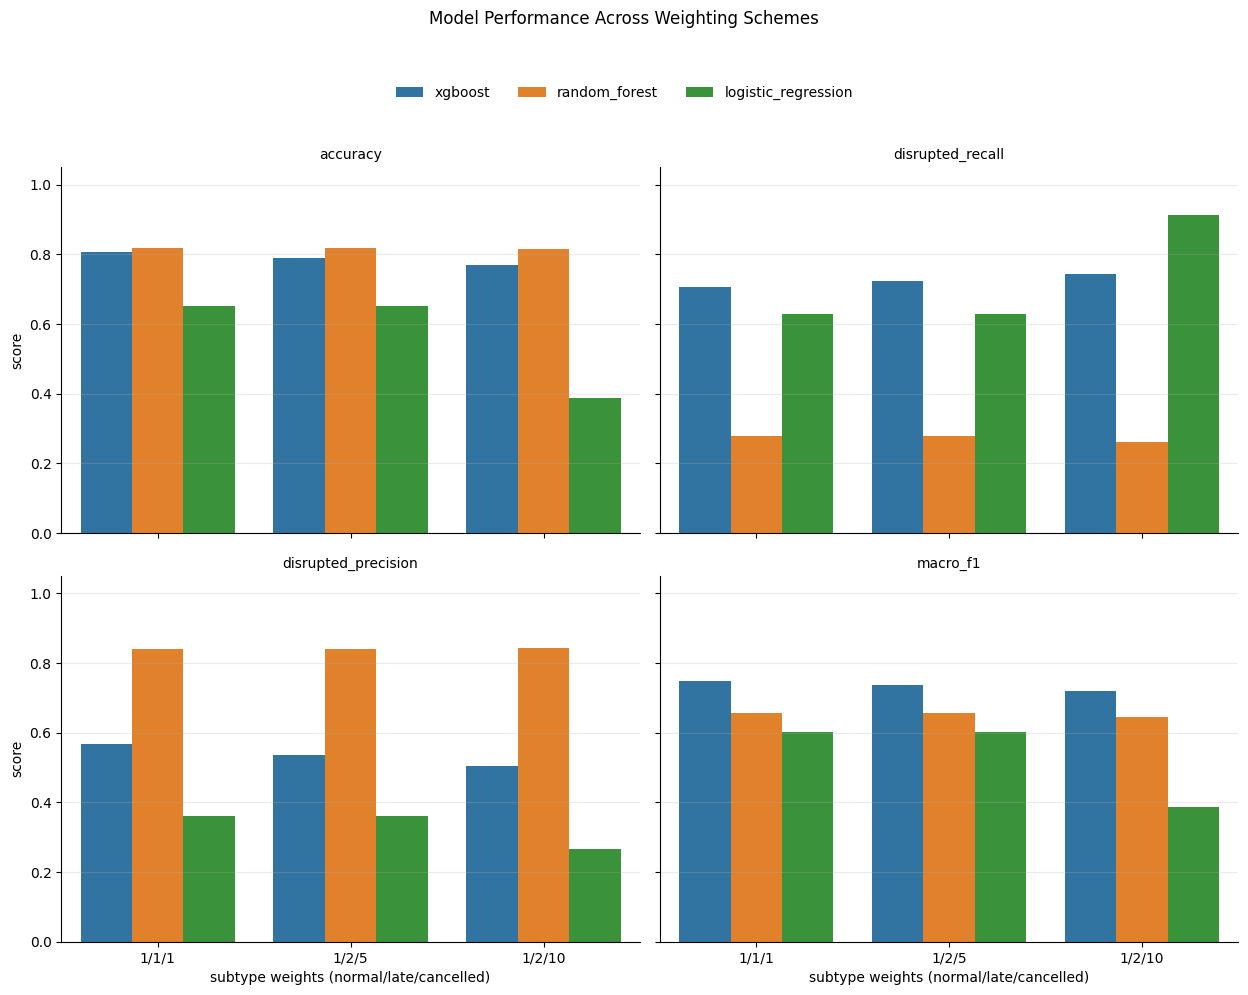

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\weighted_run_accuracy_recall_precision_macrof1.png
Accuracy by weight setting:


weights,1/1/1,1/2/10,1/2/5
model,,,
logistic_regression,0.6530,0.3888,0.6530
random_forest,0.8189,0.8159,0.8189
xgboost,0.8057,0.7693,0.7898


Disrupted recall by weight setting:


weights,1/1/1,1/2/10,1/2/5
model,,,
logistic_regression,0.6297,0.9145,0.6297
random_forest,0.2781,0.2604,0.2781
xgboost,0.7072,0.7444,0.7230


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plot_metrics = ['accuracy', 'disrupted_recall', 'disrupted_precision', 'macro_f1']
plot_df = snapshot_results.melt(
    id_vars=['weights', 'model'],
    value_vars=plot_metrics,
    var_name='metric',
    value_name='score',
)

g = sns.catplot(
    data=plot_df,
    x="weights",
    y="score",
    hue="model",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4.5,
    aspect=1.2,
    sharey=True,
)

g.set_titles("{col_name}")
g.set_axis_labels("subtype weights (normal/late/cancelled)", "score")

for ax in g.axes.flatten():
    ax.set_ylim(0, 1.12)
    ax.grid(True, axis="y", alpha=0.25)
    annotate_bar_values(ax)

if g._legend is not None:
    handles = g._legend.legend_handles
    labels = [t.get_text() for t in g._legend.texts]
    g._legend.remove()
    g.fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=max(1, len(labels)),
        bbox_to_anchor=(0.5, 1.03),
        frameon=False,
    )

g.fig.suptitle("Model Performance Across Weighting Schemes", y=1.10)
g.fig.tight_layout()

weights_plot_path = OUTPUT_DIR / 'weighted_run_accuracy_recall_precision_macrof1.png'
g.fig.savefig(weights_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print('Saved:', weights_plot_path)

pivot_accuracy = snapshot_results.pivot(index="model", columns="weights", values="accuracy")
pivot_recall = snapshot_results.pivot(index="model", columns="weights", values="disrupted_recall")

print('Accuracy by weight setting:')
display(pivot_accuracy.style.format("{:.3f}"))
print('Disrupted recall by weight setting:')
display(pivot_recall.style.format("{:.3f}"))


## Single-Flight Prediction & SHAP Explanation

Pick one flight from the **test set**, show its route (origin → destination),
run the XGBoost prediction, and draw a **SHAP waterfall plot** to explain
which features drove the model’s decision for that specific flight.

In [1]:
# ============================================================
# Single-flight prediction + SHAP TreeExplainer waterfall plot
# ============================================================
import joblib
import shap
import xgboost as xgb
from IPython.display import display

# ------------------------------------------------------------------
# 1) Load the saved XGBoost model (trained earlier in the pipeline)
# ------------------------------------------------------------------
xgb_model_path = PROJECT_ROOT / 'models' / 'xgboost.pkl'
xgb_model = joblib.load(xgb_model_path)
print(f'Loaded XGBoost model from {xgb_model_path}')

# ------------------------------------------------------------------
# 2) Pick a test-set flight — preferring a disrupted one for interest
# ------------------------------------------------------------------
disrupted_mask = y_test != normal_idx
disrupted_indices_test = X_test.index[disrupted_mask]

rng = np.random.default_rng(42)
if len(disrupted_indices_test) > 0:
    chosen_idx = rng.choice(disrupted_indices_test)
else:
    chosen_idx = rng.choice(X_test.index)

# Look up flight metadata from the original DataFrame
flight_meta = df.loc[chosen_idx, ['flight_key', 'origin', 'destination',
                                   'scheduled_dep', 'delay_minutes',
                                   'label', 'disruption_subtype']]
origin = flight_meta['origin']
destination = flight_meta['destination']

print()
print('=' * 80)
print(f'  SELECTED FLIGHT: {flight_meta["flight_key"]}')
print(f'  Route          : {origin} \u2192 {destination}')
print(f'  Scheduled dep  : {flight_meta["scheduled_dep"]}')
print(f'  Actual delay   : {flight_meta["delay_minutes"]} min')
print(f'  True label     : {flight_meta["label"]} ({flight_meta["disruption_subtype"]})')
print('=' * 80)

# ------------------------------------------------------------------
# 3) Predict with XGBoost
# ------------------------------------------------------------------
x_single = X_test.loc[[chosen_idx]]

pred_encoded = xgb_model.predict(x_single)[0]
pred_label = trainer.label_encoder.inverse_transform([int(pred_encoded)])[0]

pred_proba = xgb_model.predict_proba(x_single)[0]
proba_df = pd.DataFrame({
    'Class': trainer.label_encoder.classes_,
    'Probability': pred_proba,
}).sort_values('Probability', ascending=False)

true_encoded = y_test.loc[chosen_idx]
true_label = trainer.label_encoder.inverse_transform([int(true_encoded)])[0]

print(f'\nPredicted class : {pred_label}')
print(f'True class      : {true_label}')
print(f'Match           : {"\u2705" if pred_label == true_label else "\u274c"}')
print('\nClass probabilities:')
display(proba_df.style.format({'Probability': '{:.4f}'}).hide(axis='index'))

# ------------------------------------------------------------------
# 4) SHAP TreeExplainer — waterfall plot for the predicted class
# ------------------------------------------------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(x_single)

# For multi-class: show SHAP for the predicted class
predicted_class_idx = int(pred_encoded)

if shap_values.values.ndim == 3:
    # shape: (1, n_features, n_classes) — pick predicted class
    shap_explanation = shap.Explanation(
        values=shap_values.values[0, :, predicted_class_idx],
        base_values=shap_values.base_values[0, predicted_class_idx],
        data=shap_values.data[0],
        feature_names=shap_values.feature_names,
    )
else:
    shap_explanation = shap_values[0]

print(f'\nSHAP waterfall plot for predicted class "{pred_label}"')
print(f'Route: {origin} \u2192 {destination}\n')

shap.plots.waterfall(shap_explanation, max_display=15, show=False)
fig = plt.gcf()
fig.suptitle(
    f'SHAP Explanation \u2014 {flight_meta["flight_key"]}\n'
    f'{origin} \u2192 {destination}  |  Predicted: {pred_label}  |  True: {true_label}',
    fontsize=11,
    y=1.02,
)
fig.set_size_inches(10, 8)
plt.tight_layout()

shap_plot_path = OUTPUT_DIR / 'shap_single_flight_waterfall.png'
fig.savefig(shap_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {shap_plot_path}')

# ------------------------------------------------------------------
# 5) SHAP force plot (inline HTML)
# ------------------------------------------------------------------
shap.initjs()

if shap_values.values.ndim == 3:
    force = shap.force_plot(
        explainer.expected_value[predicted_class_idx],
        shap_values.values[0, :, predicted_class_idx],
        x_single.iloc[0],
        feature_names=list(X_test.columns),
    )
else:
    force = shap.force_plot(
        explainer.expected_value,
        shap_values.values[0],
        x_single.iloc[0],
        feature_names=list(X_test.columns),
    )

display(force)

SyntaxError: f-string expression part cannot include a backslash (2773535529.py, line 63)

Repo root: C:\Code\flight-disruption-prediction
Loaded model: xgboost
Model classes: ['Disrupted', 'Normal']
Feature count: 39

Selected test route:
KRSW -> KATL | candidate test flights on route: 8


,selected_flight
flight_key,DL1475_20220620
origin,KRSW
destination,KATL
scheduled_dep,2022-06-20 12:20:00+00:00
scheduled_arr,2022-06-20 13:58:00+00:00
label,Normal
label_binary,Normal
disruption_subtype,Normal
delay_minutes,-3.0



Prediction percentages:


,class,probability,probability_%
0,Normal,0.972943,97.293999
1,Disrupted,0.027057,2.706000


,item,value
0,Argmax predicted class,Normal
1,Threshold decision at disrupted >= 0.50,Normal
2,Disrupted probability,2.706%
3,Normal probability,97.294%
4,Actual binary label,Normal
5,Actual original label,Normal
6,Actual delay minutes,-3.0



Top 15 SHAP drivers for Disrupted:
Positive SHAP value = pushes prediction toward Disrupted risk. Negative = pushes toward Normal.


,feature,raw_value,shap_value_for_disrupted
0,ping_interval_cv,1.740000e-01,-1.200
1,altitude_variance,1.950546e+07,-0.334
2,dep_hour,1.200000e+01,-0.300
3,max_inter_ping_seconds,6.000000e+01,0.299
4,dest_flight_count,1.383000e+04,0.194
5,vertical_rate_std,7.114000e+00,-0.163
6,dest_flights_1hr,9.200000e+01,0.124
7,dep_month,6.000000e+00,0.117
8,mean_speed,2.016270e+02,0.112
9,dep_day_of_week,0.000000e+00,-0.103


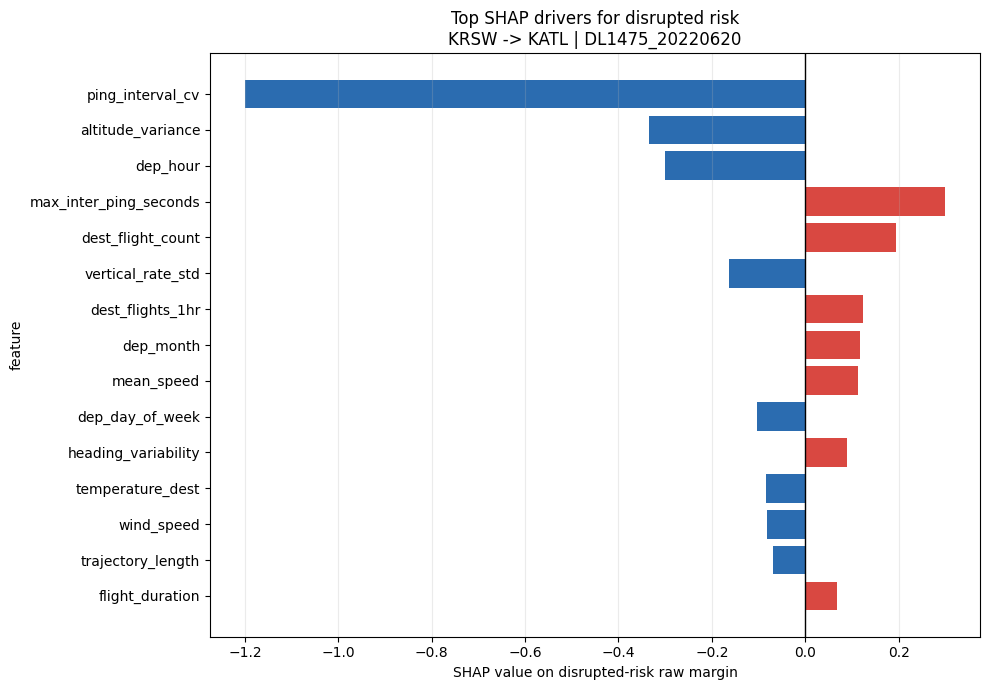

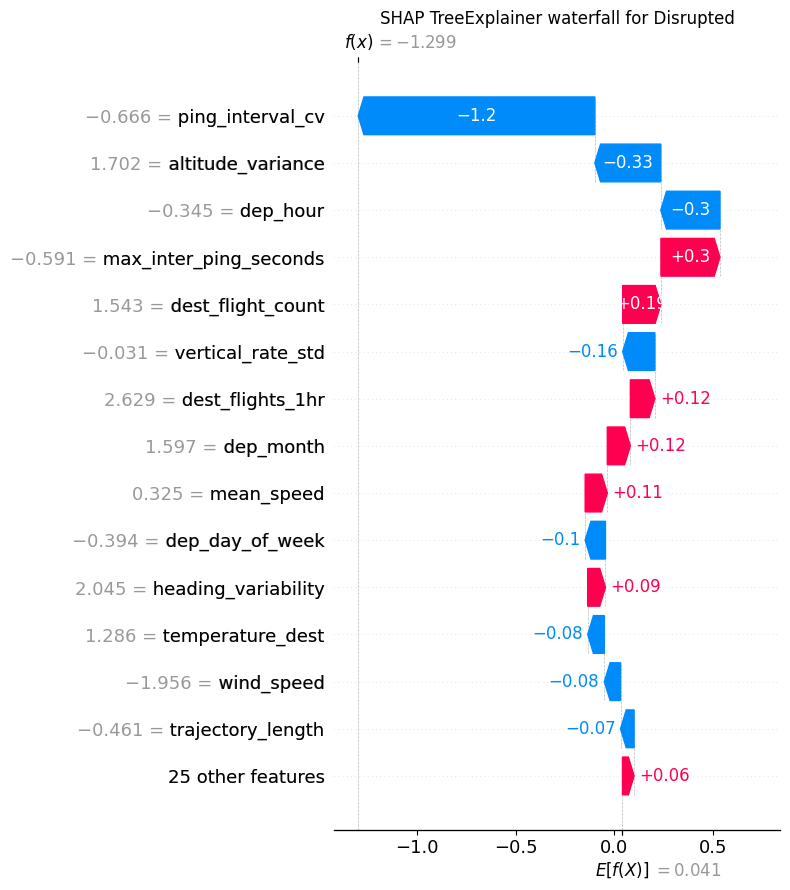

In [2]:
# Random test-route prediction with SHAP TreeExplainer
# Picks one random origin -> destination pair from the held-out test window,
# selects one random flight on that route, predicts class percentages,
# and explains disrupted-risk drivers using SHAP TreeExplainer.

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display

# -----------------------------
# Settings
# -----------------------------
MODEL_NAME = "xgboost"          # TreeExplainer works well for xgboost/random_forest. Logistic regression is not a tree model.
DISRUPTION_THRESHOLD = 0.50      # Change this if you want a business-threshold decision instead of default 0.50.
RANDOM_SEED = None               # Set an integer, e.g. 42, for repeatable random selection.
TOP_N_SHAP = 15

# Optional manual route override. Leave as None for random route from test set.
# Example: ROUTE_FILTER = ("KLAX", "KMIA")
ROUTE_FILTER = None

# -----------------------------
# Resolve repo paths robustly from notebook or repo root
# -----------------------------
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / "models" / f"{MODEL_NAME}.pkl").exists() and (candidate / "data" / "processed" / "ml_dataset.parquet").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find repo root containing models/ and data/processed/ml_dataset.parquet")

model_path = REPO_ROOT / "models" / f"{MODEL_NAME}.pkl"
feature_path = REPO_ROOT / "models" / "feature_list.json"
imputer_path = REPO_ROOT / "models" / "imputer.pkl"
scaler_path = REPO_ROOT / "models" / "scaler.pkl"
encoder_path = REPO_ROOT / "models" / "label_encoder.pkl"
ml_path = REPO_ROOT / "data" / "processed" / "ml_dataset.parquet"

# -----------------------------
# Load artifacts
# -----------------------------
model = joblib.load(model_path)
imputer = joblib.load(imputer_path)
scaler = joblib.load(scaler_path)
label_encoder = joblib.load(encoder_path)
feature_cols = json.loads(feature_path.read_text(encoding="utf-8"))
classes = list(label_encoder.classes_)

print(f"Repo root: {REPO_ROOT}")
print(f"Loaded model: {MODEL_NAME}")
print(f"Model classes: {classes}")
print(f"Feature count: {len(feature_cols)}")

# -----------------------------
# Load only columns needed for prediction + metadata
# -----------------------------
try:
    import pyarrow.parquet as pq
    available_cols = pq.ParquetFile(ml_path).schema.names
except Exception:
    available_cols = pd.read_parquet(ml_path, engine="pyarrow").columns.tolist()

meta_cols = [
    "flight_key", "callsign", "origin", "destination", "scheduled_dep", "scheduled_arr",
    "label", "label_binary", "disruption_subtype", "delay_minutes", "training_eligible",
]
load_cols = [c for c in dict.fromkeys(meta_cols + feature_cols) if c in available_cols]
df = pd.read_parquet(ml_path, columns=load_cols)

# Match training eligibility and binary target preparation.
if "training_eligible" in df.columns:
    df = df[df["training_eligible"] == True].copy()
if "label" in df.columns:
    df = df[df["label"] != "Unverified"].copy()

if "label_binary" not in df.columns:
    df["label_binary"] = np.where(df["label"].astype(str).eq("Normal"), "Normal", "Disrupted")
else:
    fallback_binary = np.where(df["label"].astype(str).eq("Normal"), "Normal", "Disrupted")
    df["label_binary"] = df["label_binary"].where(df["label_binary"].isin(["Normal", "Disrupted"]), fallback_binary)

# Reproduce final pipeline temporal test split: last 7 observed scheduled-departure days.
df["scheduled_dep_dt"] = pd.to_datetime(df["scheduled_dep"], utc=True, errors="coerce")
dep_dates = df["scheduled_dep_dt"].dt.normalize()
unique_days = sorted(dep_dates.dropna().unique())
if len(unique_days) < 7:
    raise ValueError("Fewer than 7 scheduled-departure days available; cannot reproduce the temporal test split.")

test_start = pd.Timestamp(unique_days[-7])
if test_start.tzinfo is None:
    test_start = test_start.tz_localize("UTC")

test_df = df[dep_dates >= test_start].copy()
test_df = test_df.dropna(subset=["origin", "destination"])
if test_df.empty:
    raise ValueError("No test rows with origin/destination available.")

# -----------------------------
# Pick random A -> B route, then one random flight on that route
# -----------------------------
rng = np.random.default_rng(RANDOM_SEED)

if ROUTE_FILTER is not None:
    origin_filter, destination_filter = ROUTE_FILTER
    route_df = test_df[
        test_df["origin"].astype(str).eq(origin_filter)
        & test_df["destination"].astype(str).eq(destination_filter)
    ].copy()
    if route_df.empty:
        raise ValueError(f"No test flights found for route {origin_filter} -> {destination_filter}")
    route_origin, route_destination = origin_filter, destination_filter
else:
    routes = test_df[["origin", "destination"]].drop_duplicates().reset_index(drop=True)
    route_idx = int(rng.integers(0, len(routes)))
    route_origin = str(routes.loc[route_idx, "origin"])
    route_destination = str(routes.loc[route_idx, "destination"])
    route_df = test_df[
        test_df["origin"].astype(str).eq(route_origin)
        & test_df["destination"].astype(str).eq(route_destination)
    ].copy()

selected = route_df.sample(n=1, random_state=None if RANDOM_SEED is None else int(rng.integers(0, 2**32 - 1))).iloc[0]
selected_df = selected.to_frame().T

print("\nSelected test route:")
print(f"{route_origin} -> {route_destination} | candidate test flights on route: {len(route_df):,}")

selected_meta_cols = [c for c in [
    "flight_key", "callsign", "origin", "destination", "scheduled_dep", "scheduled_arr",
    "label", "label_binary", "disruption_subtype", "delay_minutes"
] if c in selected_df.columns]
display(selected_df[selected_meta_cols].T.rename(columns={selected_df.index[0]: "selected_flight"}))

# -----------------------------
# Transform features exactly like app/training artifacts
# -----------------------------
X_raw = selected_df.reindex(columns=feature_cols).copy()
for col in X_raw.columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

X_imp = pd.DataFrame(imputer.transform(X_raw), columns=feature_cols, index=X_raw.index)
X_scaled = pd.DataFrame(scaler.transform(X_imp), columns=feature_cols, index=X_raw.index)

# -----------------------------
# Predict probabilities
# -----------------------------
if not hasattr(model, "predict_proba"):
    raise TypeError(f"{MODEL_NAME} does not expose predict_proba().")

probs = model.predict_proba(X_scaled)[0]
prob_table = (
    pd.DataFrame({"class": classes, "probability": probs, "probability_%": probs * 100})
    .sort_values("probability", ascending=False)
    .reset_index(drop=True)
)

class_to_prob = dict(zip(classes, probs))
disrupted_prob = float(class_to_prob.get("Disrupted", np.nan))
normal_prob = float(class_to_prob.get("Normal", np.nan))
threshold_decision = "Disrupted" if disrupted_prob >= DISRUPTION_THRESHOLD else "Normal"
argmax_label = prob_table.loc[0, "class"]

print("\nPrediction percentages:")
display(prob_table.assign(**{"probability_%": prob_table["probability_%"].round(3)}))

summary = pd.DataFrame([
    {"item": "Argmax predicted class", "value": argmax_label},
    {"item": f"Threshold decision at disrupted >= {DISRUPTION_THRESHOLD:.2f}", "value": threshold_decision},
    {"item": "Disrupted probability", "value": f"{disrupted_prob * 100:.3f}%"},
    {"item": "Normal probability", "value": f"{normal_prob * 100:.3f}%"},
    {"item": "Actual binary label", "value": selected.get("label_binary", "not available")},
    {"item": "Actual original label", "value": selected.get("label", "not available")},
    {"item": "Actual delay minutes", "value": selected.get("delay_minutes", "not available")},
])
display(summary)

# -----------------------------
# SHAP TreeExplainer
# -----------------------------
# Important: for this binary XGBoost model, LabelEncoder classes are usually ['Disrupted', 'Normal'].
# XGBoost's binary raw margin normally explains encoded class 1, which is 'Normal'.
# To show drivers of disrupted risk, we invert the raw-margin SHAP values when class 1 is Normal.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)
expected_value = explainer.expected_value

explained_class = "Disrupted"
shap_arr = np.asarray(shap_values, dtype=object)

if isinstance(shap_values, list):
    disrupted_idx = classes.index("Disrupted") if "Disrupted" in classes else int(np.argmax(probs))
    shap_for_disrupted = np.asarray(shap_values[disrupted_idx])[0]
    base_for_disrupted = np.asarray(expected_value).ravel()[disrupted_idx]
elif np.asarray(shap_values).ndim == 3:
    disrupted_idx = classes.index("Disrupted") if "Disrupted" in classes else int(np.argmax(probs))
    shap_for_disrupted = np.asarray(shap_values)[0, :, disrupted_idx]
    base_for_disrupted = np.asarray(expected_value).ravel()[disrupted_idx]
else:
    raw_shap = np.asarray(shap_values)[0]
    raw_base = float(np.asarray(expected_value).ravel()[0])
    if len(classes) == 2 and classes[1] == "Normal" and "Disrupted" in classes:
        shap_for_disrupted = -raw_shap
        base_for_disrupted = -raw_base
        explained_class = "Disrupted (inverted from class-1 Normal raw margin)"
    else:
        shap_for_disrupted = raw_shap
        base_for_disrupted = raw_base
        explained_class = classes[1] if len(classes) == 2 else argmax_label

shap_table = pd.DataFrame({
    "feature": feature_cols,
    "raw_value": X_raw.iloc[0].values,
    "scaled_value": X_scaled.iloc[0].values,
    "shap_value_for_disrupted": shap_for_disrupted,
})
shap_table["abs_shap"] = shap_table["shap_value_for_disrupted"].abs()
shap_table = shap_table.sort_values("abs_shap", ascending=False).reset_index(drop=True)

print(f"\nTop {TOP_N_SHAP} SHAP drivers for {explained_class}:")
print("Positive SHAP value = pushes prediction toward Disrupted risk. Negative = pushes toward Normal.")
display(
    shap_table.head(TOP_N_SHAP)[["feature", "raw_value", "shap_value_for_disrupted"]]
    .assign(
        raw_value=lambda d: pd.to_numeric(d["raw_value"], errors="coerce").round(3),
        shap_value_for_disrupted=lambda d: d["shap_value_for_disrupted"].round(3),
    )
)

# Bar chart for report/notebook readability.
plot_df = shap_table.head(TOP_N_SHAP).iloc[::-1]
colors = np.where(plot_df["shap_value_for_disrupted"] >= 0, "#D94841", "#2B6CB0")
plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["shap_value_for_disrupted"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top SHAP drivers for disrupted risk\n{route_origin} -> {route_destination} | {selected.get('flight_key', '')}")
plt.xlabel("SHAP value on disrupted-risk raw margin")
plt.ylabel("feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Optional SHAP waterfall. Values shown use scaled feature space because that is what the model received.
try:
    explanation = shap.Explanation(
        values=np.asarray(shap_for_disrupted, dtype=float),
        base_values=float(base_for_disrupted),
        data=X_scaled.iloc[0].values,
        feature_names=feature_cols,
    )
    shap.plots.waterfall(explanation, max_display=TOP_N_SHAP, show=False)
    plt.title(f"SHAP TreeExplainer waterfall for {explained_class}")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Waterfall plot skipped: {exc}")
